# Análise exploratória — Camada Silver

Lê as 4 tabelas gravadas pelo `pipeline/silver/silver_transform.py` no bucket `tc-fase2-alfabetizacao-silver` e dá uma primeira olhada nos dados já tratados (rede decodificada, `id_municipio` normalizado, metas unpivotadas e joinadas com o resultado real).

In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

SILVER_BUCKET = "tc-fase2-alfabetizacao-silver"
client = boto3.client("s3", region_name="us-east-1")

In [2]:
def get_ultima_particao(bucket, prefixo):
    response = client.list_objects_v2(Bucket=bucket, Prefix=prefixo)
    chaves = [obj["Key"] for obj in response.get("Contents", [])]
    particoes = {parte for chave in chaves for parte in chave.split("/") if parte.startswith("ingestion_date=")}
    if not particoes:
        raise ValueError(f"Nenhuma partição encontrada em s3://{bucket}/{prefixo}")
    return sorted(particoes)[-1]


def ler_silver(tabela):
    particao = get_ultima_particao(SILVER_BUCKET, f"{tabela}/")
    caminho = f"s3://{SILVER_BUCKET}/{tabela}/{particao}/data.parquet"
    print(f"Lendo {caminho}")
    return pd.read_parquet(caminho)

In [3]:
alunos = ler_silver("alunos")
resultado_municipio = ler_silver("resultado_municipio_x_meta")
resultado_uf = ler_silver("resultado_uf_x_meta")
meta_brasil = ler_silver("meta_brasil")

Lendo s3://tc-fase2-alfabetizacao-silver/alunos/ingestion_date=2026-07-02/data.parquet
Lendo s3://tc-fase2-alfabetizacao-silver/resultado_municipio_x_meta/ingestion_date=2026-07-02/data.parquet
Lendo s3://tc-fase2-alfabetizacao-silver/resultado_uf_x_meta/ingestion_date=2026-07-02/data.parquet
Lendo s3://tc-fase2-alfabetizacao-silver/meta_brasil/ingestion_date=2026-07-02/data.parquet


## `alunos`

In [4]:
print(alunos.shape)
alunos.head()

(3867999, 16)


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,_ingestion_date,_source_file,ingestion_date,rede_padranizado
0,2023,2211001,60006431,22034277,1,2,3,0,0,False,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_alunos.csv,2026-07-02,Municipal
1,2023,4205407,60034824,42034973,1,2,2,0,0,False,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_alunos.csv,2026-07-02,Estadual
2,2023,4301602,60039942,43025289,1,2,3,0,0,False,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_alunos.csv,2026-07-02,Municipal
3,2024,1302603,60000925,13033107,1,2,2,0,0,False,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_alunos.csv,2026-07-02,Estadual
4,2024,1502152,60003041,15022792,1,2,3,0,0,False,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_alunos.csv,2026-07-02,Municipal


In [5]:
alunos.dtypes

ano                         int64
id_municipio               object
id_escola                   int64
id_aluno                    int64
caderno                     int64
serie                       int64
rede                        int64
presenca                    int64
preenchimento_caderno       int64
alfabetizado                 bool
proficiencia              float64
peso_aluno                float64
_ingestion_date            object
_source_file               object
ingestion_date           category
rede_padranizado           object
dtype: object

In [6]:
alunos["rede_padranizado"].value_counts()

rede_padranizado
Municipal    3432576
Estadual      435398
Privada           25
Name: count, dtype: int64

In [7]:
alunos.isna().mean().sort_values(ascending=False) * 100

proficiencia             13.27141
peso_aluno               13.27141
ano                       0.00000
id_municipio              0.00000
id_escola                 0.00000
id_aluno                  0.00000
caderno                   0.00000
serie                     0.00000
rede                      0.00000
presenca                  0.00000
preenchimento_caderno     0.00000
alfabetizado              0.00000
_ingestion_date           0.00000
_source_file              0.00000
ingestion_date            0.00000
rede_padranizado          0.00000
dtype: float64

## `resultado_municipio_x_meta`

In [8]:
print(resultado_municipio.shape)
resultado_municipio.head()

(23995, 20)


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,_ingestion_date,_source_file,ingestion_date,rede_padranizado,valor_meta
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_municipio.csv,2026-07-02,Municipal,NaN
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_municipio.csv,2026-07-02,Municipal,NaN
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_municipio.csv,2026-07-02,Pública (Estadual e Municipal),NaN
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_municipio.csv,2026-07-02,Municipal,NaN
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_municipio.csv,2026-07-02,Municipal,NaN


In [9]:
resultado_municipio[["taxa_alfabetizacao", "media_portugues", "valor_meta"]].describe()

,taxa_alfabetizacao,media_portugues,valor_meta
count,23995.000000,23995.000000,5232.000000
mean,61.444545,751.375708,62.151745
std,19.743521,23.232837,15.098183
min,2.120000,673.298300,7.940000
25%,47.170000,736.035750,52.170000
50%,62.230000,750.654200,64.095000
75%,76.550000,764.302900,75.885000
max,100.000000,868.455400,80.000000


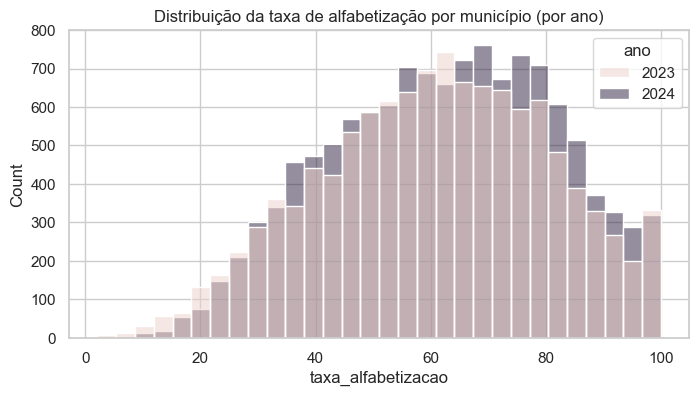

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=resultado_municipio, x="taxa_alfabetizacao", hue="ano", bins=30, ax=ax)
ax.set_title("Distribuição da taxa de alfabetização por município (por ano)")
plt.show()

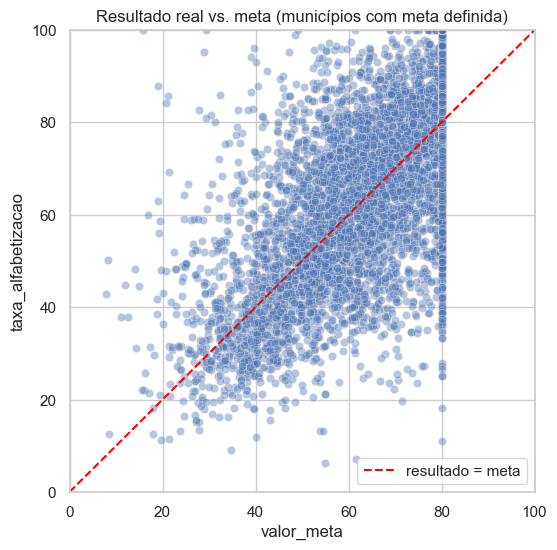

In [11]:
comparavel = resultado_municipio[resultado_municipio["valor_meta"].notna()]
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=comparavel, x="valor_meta", y="taxa_alfabetizacao", alpha=0.4, ax=ax)
lim = [0, 100]
ax.plot(lim, lim, linestyle="--", color="red", label="resultado = meta")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_title("Resultado real vs. meta (municípios com meta definida)")
ax.legend()
plt.show()

## `resultado_uf_x_meta`

In [12]:
print(resultado_uf.shape)
resultado_uf.head()

(145, 20)


,ano,sigla_uf,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,_ingestion_date,_source_file,ingestion_date,rede_padranizado,valor_meta
0,2023,AM,2,3,49.20,733.6637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_uf.csv,2026-07-02,Municipal,NaN
1,2023,PB,2,2,55.23,744.8152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_uf.csv,2026-07-02,Estadual,NaN
2,2023,PR,2,5,73.12,757.2146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_uf.csv,2026-07-02,Pública (Estadual e Municipal),NaN
3,2023,AP,2,3,41.87,732.7858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_uf.csv,2026-07-02,Municipal,NaN
4,2023,PE,2,5,58.95,747.4522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-29,br_inep_avaliacao_alfabetizacao_uf.csv,2026-07-02,Pública (Estadual e Municipal),NaN


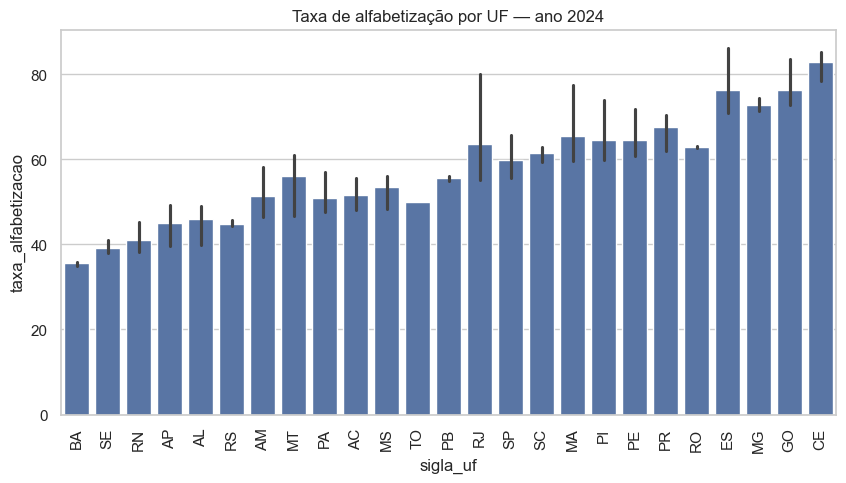

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ordenado = resultado_uf[resultado_uf["ano"] == resultado_uf["ano"].max()].sort_values("taxa_alfabetizacao")
sns.barplot(data=ordenado, x="sigla_uf", y="taxa_alfabetizacao", ax=ax)
ax.set_title(f"Taxa de alfabetização por UF — ano {resultado_uf['ano'].max()}")
plt.xticks(rotation=90)
plt.show()

## `meta_brasil`

In [14]:
meta_brasil.head(10)

,ano,rede,taxa_alfabetizacao,percentual_participacao,_ingestion_date,_source_file,ingestion_date,valor_meta,ano_meta
0,2025,Pública,66.0,88.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,60.00,2024
1,2024,Pública,59.2,87.37,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,59.90,2024
2,2023,Pública,55.9,86.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,59.90,2024
3,2025,Pública,66.0,88.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,64.00,2025
4,2024,Pública,59.2,87.37,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,63.77,2025
5,2023,Pública,55.9,86.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,63.77,2025
6,2025,Pública,66.0,88.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,67.00,2026
7,2024,Pública,59.2,87.37,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,67.47,2026
8,2023,Pública,55.9,86.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,67.47,2026
9,2025,Pública,66.0,88.00,2026-06-29,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,2026-07-02,71.00,2027



- Comparar `proporcao_aluno_nivel_*` entre municípios (lembre: só existe pra `ano=2024`).
- Cruzar `alunos` com `resultado_municipio_x_meta` por `id_municipio` pra ver a distribuição de `proficiencia` nos municípios com maior/menor gap.
- Olhar as tabelas da camada Gold (`comparacao_meta_municipio`, `evolucao_temporal_municipio`) do mesmo jeito, trocando `SILVER_BUCKET` por `tc-fase2-alfabetizacao-gold`.